# System 7: $V(r) = -10e^{-r^2}+0.1e^{-(r-3)^2/1.5^2}$, $s$-wave bound state, narrow $p$-wave resonance.
- Supports an $s$-wave bound state at $E_b=-2.52748761$.
- Supports a $p$-wave resonance at $E_r=0.36060844 - i0.14112758 $
    - $\phi_\text{min}=\text{arg}(E) / 2 \approx 0.1865$.
    - $V(r)$ is a Gaussian, so $\phi_\text{max}=\pi/4\approx0.785$
- $\phi_\text{min} \le \phi < \phi_\text{max} = 0.1865 \le \phi < 0.785$.
- By $r=10$, $V(r=10)\propto 10^{-11} \approx 0$.

Due to finite volume effects, the good region of $\phi$ might vary from its theoretical value. This is a very narrow resonance. This gives
EC a much larger region to train over and a much smaller gap to extrapolate across for back-rotation.

In [1]:
from src.ecensemble import ECEnsemble
from src.ec import ECSystem
from src.dvr import DVR
from src.utils import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
save_plots = True
plots_folder = get_plots_path() / "system_7"
plots_folder.mkdir(exist_ok=True, parents=True)

In [3]:
n = 256
L_stable = 55.0
phi_stable = 0.5

real_res = 0.36129249 - 1j*0.141932 
real_bound = -2.527488195 + 1j*0.0
real_telem = 1.0214491 - 1j*0.207384899
real_rr = 0.4941383 + 1j*0.5376738

V_0, R = 10.0, 1.0
r_b, w, V_b = 3.0, 1.5, 0.1
def gauss_barrier(r):
    att_gauss = -V_0 * np.exp(-r**2/R**2)
    extra_barr = V_b * np.exp(-(r-r_b)**2/w**2)
    return att_gauss + extra_barr

In [4]:
sbound_system = DVR(n, L_stable, rotation_angle=0.0, potential=gauss_barrier, l=0)
pres_system = DVR(n, L_stable, rotation_angle=phi_stable, potential=gauss_barrier, l=1)

### Plot the good region of $\phi$ for system 7

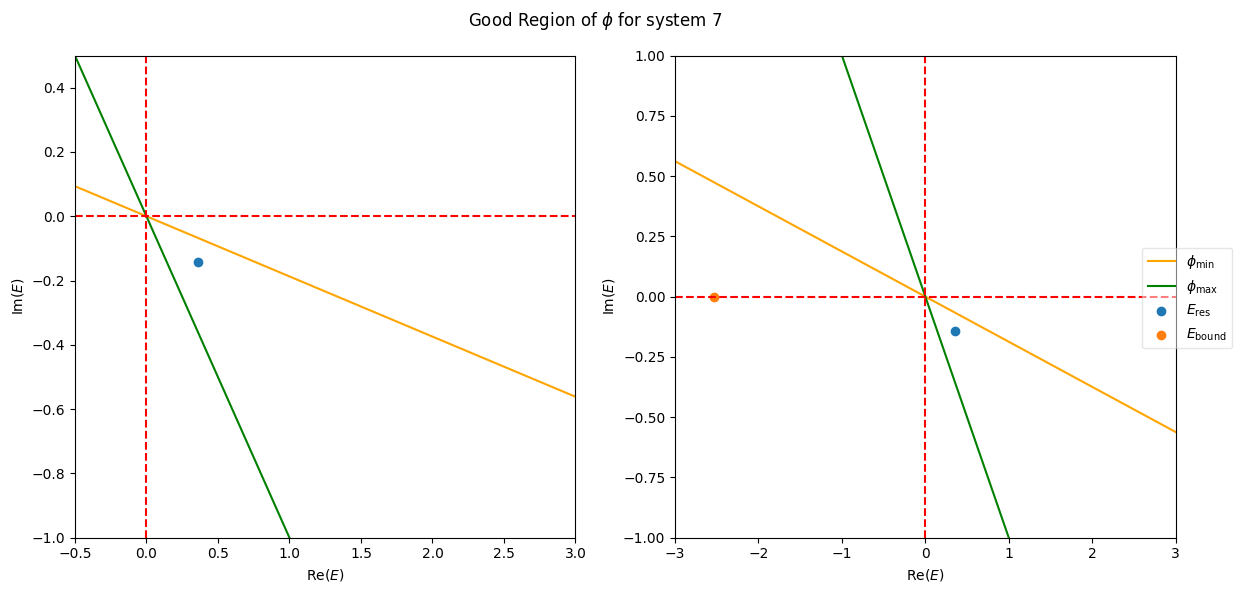

In [5]:
fig, (axres, axbound) = plt.subplots(1, 2, figsize=(12,6))
axres.set_xlim([-.5, 3.0])
axres.set_ylim([-1.0, 0.5])
axbound.set_xlim([-3.0, 3])
axbound.set_ylim([-1.0, 1.0])
for ax in (axres, axbound):
    ax.axline((0,0), (1, np.angle(real_res)/2), color='orange', label=r'$\phi_\text{min}$')
    ax.axline((0,0), (1, -np.tan(np.pi/4)), color='green', label=r'$\phi_\text{max}$')
    ax.axvline(0, linestyle='--', color='red')
    ax.axhline(0, linestyle='--', color='red')
    ax.scatter(np.real(real_res), np.imag(real_res), label=r'$E_\text{res}$')
    ax.set_xlabel(r"Re$(E)$")
    ax.set_ylabel(r"Im$(E)$")
    ax.legend().remove()
axbound.scatter(np.real(real_bound), np.imag(real_bound), label=r'$E_\text{bound}$')
fig.suptitle(r"Good Region of $\phi$ for system 7")
handles, labels = axbound.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.95, 0.5), framealpha=0.5)
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "phi_good_region.png")
plt.show()

### Plot the spectrum for the $p$-wave resonance system

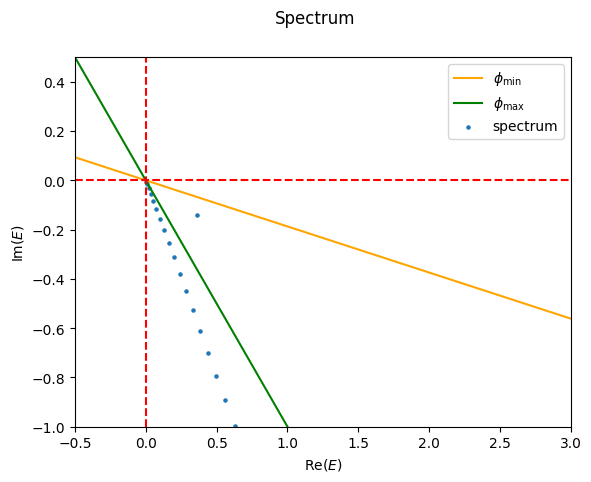

In [6]:
eigvals, _ = pres_system.eig()
fig, ax = plt.subplots()
ax.axline((0,0), (1, np.angle(real_res)/2), color='orange', label=r'$\phi_\text{min}$')
ax.axline((0,0), (1, -np.tan(np.pi/4)), color='green', label=r'$\phi_\text{max}$')
ax.scatter(np.real(eigvals), np.imag(eigvals), label='spectrum', s=5)
ax.axvline(0, linestyle='--', color='red')
ax.axhline(0, linestyle='--', color='red')
ax.set_xlabel(r"Re$(E)$")
ax.set_ylabel(r"Im$(E)$")
ax.legend()
ax.set_xlim([-0.5, 3.0])
ax.set_ylim([-1.0, 0.5])
fig.suptitle(r"Spectrum")
plt.show()

### $E(L)$, $(r_\theta^2)(L)$, $(\psi_\text{res}|r|\psi_\text{bound})$ at fixed $\phi$.

In [7]:
# compute <r^2> as L varies
Ls = np.linspace(50.0, 100., 100)
energies, rrs, telems = [], [], []

for L in Ls:
    tbound = DVR(n, L, rotation_angle=phi_stable, potential=gauss_barrier, l=0)
    tres = DVR(n, L, rotation_angle=phi_stable, potential=gauss_barrier, l=1)

    b_energy, b_state = tbound.closest_to_resonance(real_bound)
    r_energy, r_state = tres.closest_to_resonance(real_res)
    
    rr = tres.compute_rr(r_state[:, 0], rotate_rr=True)
    telem = DVR.compute_transition_mat_element(L, b_state[:, 0], r_state[:, 0], rotation_angle=phi_stable, operator="E1")

    telems.append(telem)
    energies.append(r_energy[0])
    rrs.append(rr)

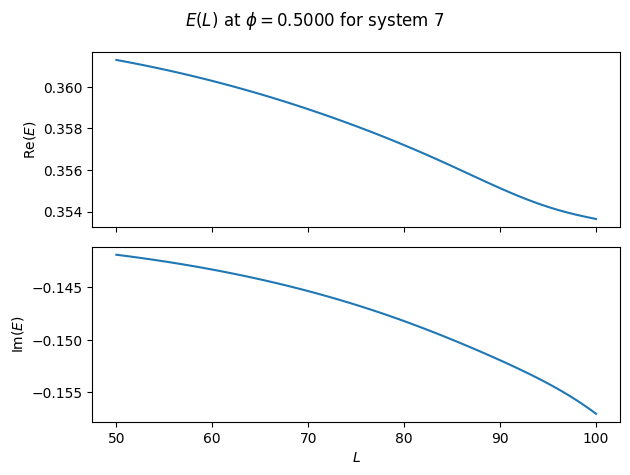

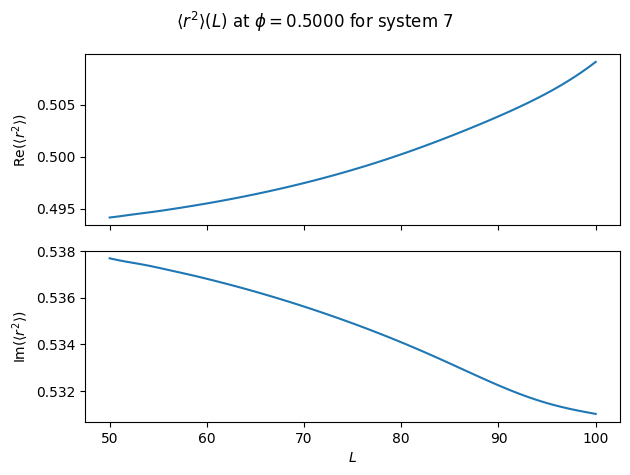

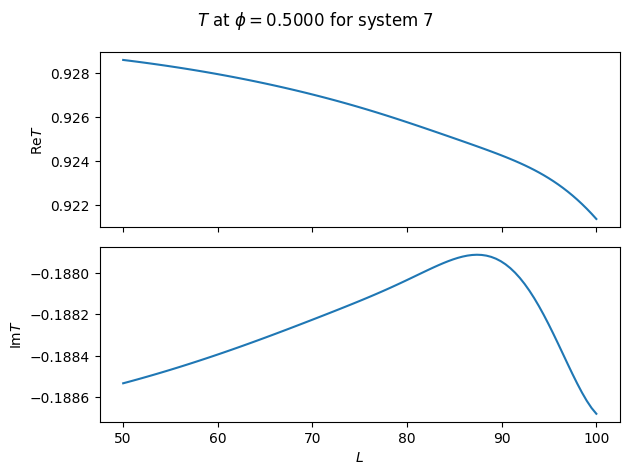

In [8]:
# plot E(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(energies))
ax2.plot(Ls, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$E(L)$ at $\phi=${phi_stable:.4f} for system 7")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "E_stability_L")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(rrs))
ax2.plot(Ls, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$\langle r^2\rangle(L)$ at $\phi=${phi_stable:.4f} for system 7")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "rr_stability_L.png")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(telems))
ax2.plot(Ls, np.imag(telems))
ax1.set_ylabel(r"Re$T$")
ax2.set_ylabel(r"Im$T$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$T$ at $\phi=${phi_stable:.4f} for system 7")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "telem_stability_L.png")
plt.show()

### $E(\phi)$, $(r^2)(\theta)$, $(\psi_\text{res}|r|\psi_\text{bound})$ at fixed $L$.

In [19]:
# compute E and <r^2> as phi varies
# the ABC theorem says that this should be const.
phis = np.linspace(0.4, 0.6, 100)
energies, rrs, telems = [], [], []

for phi in phis:
    sbound_system.reset_rotation_angle(phi)
    pres_system.reset_rotation_angle(phi)
    
    b_energy, b_state = sbound_system.closest_to_resonance(real_bound)
    r_energy, r_state = pres_system.closest_to_resonance(real_res)
    
    rr = pres_system.compute_rr(r_state[:, 0], rotate_rr=True)
    telem = DVR.compute_transition_mat_element(L_stable, b_state[:, 0], r_state[:, 0], rotation_angle=phi, operator="E1")

    telems.append(telem)
    energies.append(r_energy[0])
    rrs.append(rr)

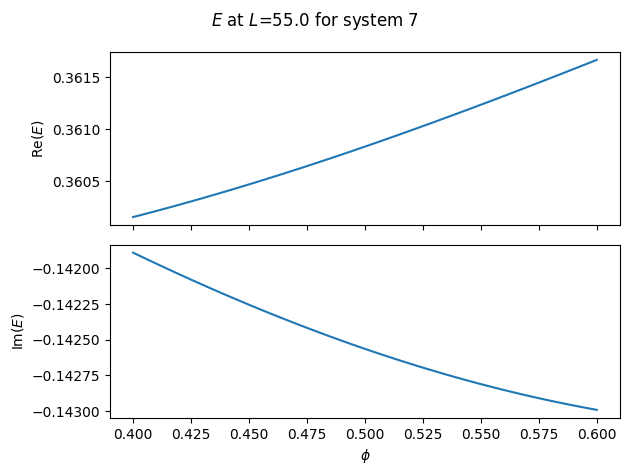

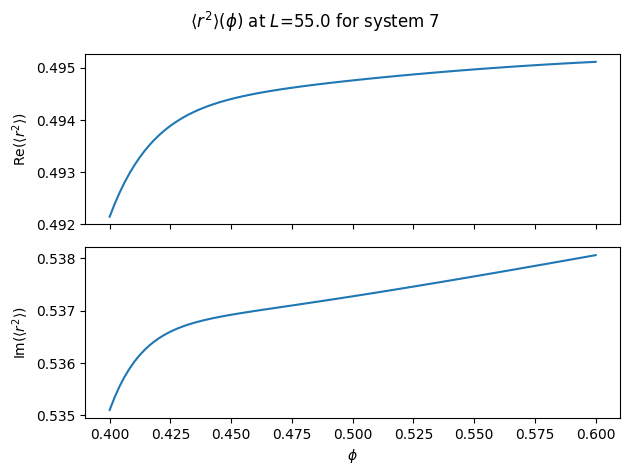

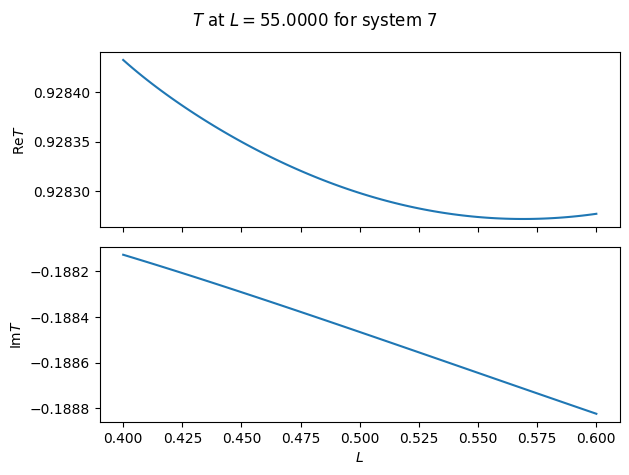

In [20]:
# plot <E>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(energies))
ax2.plot(phis, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(fr"$E$ at $L$={L_stable} for system 7")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "E_stability_phi.png")
plt.show()

# plot <r^2>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(rrs))
ax2.plot(phis, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(fr"$\langle r^2\rangle(\phi)$ at $L$={L_stable} for system 7")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "rr_stability_phi.png")
plt.show()

# plot transition matrix elements
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(telems))
ax2.plot(phis, np.imag(telems))
ax1.set_ylabel(r"Re$T$")
ax2.set_ylabel(r"Im$T$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$T$ at $L=${L_stable:.4f} for system 7")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "telem_stability_phi.png")
plt.show()

### Using EC to predict $(r^2)$, $E$, and $(\psi_\text{res}|r|\psi_\text{bound})$.
The good region seems to be about $\phi\in [0.4, 0.6]$.


In [11]:
# define function to quickly check bound / resonance energy, transition matrix element, and residuals using EC
def quick_predict(phi_predict, ec_system):
    # get bound state (no need to use EC here). This shouldn't change at all
    sbound_system.reset_rotation_angle(phi_predict)
    energies, states = sbound_system.closest_to_resonance(resonance=real_bound)
    bound_energy, bound_state = energies[0], states[:, 0]
    resid = np.abs(real_bound.real - bound_energy.real) + 1j*np.abs(real_bound.imag - bound_energy.imag)
    print(f"Bound state energy at phi={phi_predict}: {bound_energy.real:.4f} + i{bound_energy.imag:.4f}")
    print(f"\t Residual: {resid.real:.4f} + i{resid.imag:.4f}")
    
    # get predicted resonance using EC
    energy, backrot_prediction = ec_system.predict_DVR_state_at(phi_predict)
    resid = np.abs(real_res.real - energy.real) + 1j*np.abs(real_res.imag - energy.imag)
    print(f"Resonance energy prediction at phi={phi_predict:.4f}: {energy.real:.4f} + i{energy.imag:.4f}")
    print(f"\t Residual: {resid.real:.4f} + i{resid.imag:.4f}")
    
    # get trans element
    trans_elem = DVR.compute_transition_mat_element(L_stable, bound_state, backrot_prediction, rotation_angle=phi_predict, operator="E1")
    trans_elem *= np.sign(trans_elem.real) # trans elem fixed to arbitrary +- 1; we choose positive real part
    resid = np.abs(real_telem.real - trans_elem.real) + 1j*np.abs(real_telem.imag - trans_elem.imag)
    print(f"Transition matrix element prediction at phi={phi_predict:.4f}: {trans_elem.real:.4f} + i{trans_elem.imag:.4f}")
    print(f"\t Residual: {resid.real:.4f} + i{resid.imag:.4f}")
    return energy, trans_elem

def get_training_data(phi_train):
    bound_energies = []
    training_energies, training_rrs, training_telems = [], [], []
    for phi in phi_train:
        sbound_system.reset_rotation_angle(phi)
        pres_system.reset_rotation_angle(phi)

        b_energy, bound_state = sbound_system.closest_to_resonance(real_bound)
        bound_state = bound_state[:, 0]
        bound_energies.append(b_energy[0])

        energy, res_state = pres_system.closest_to_resonance(real_res)
        energy, res_state = energy[0], res_state[:, 0]
        rr = pres_system.compute_rr(res_state, rotate_rr=True)
        
        telem = DVR.compute_transition_mat_element(L_stable, bound_state, res_state, rotation_angle=phi, operator="E1")
        telem *= np.sign(np.real(telem))

        training_energies.append(energy)
        training_rrs.append(rr)
        training_telems.append(telem)
    training_energies = np.array(training_energies)
    training_rrs = np.array(training_rrs)
    training_telems = np.array(training_telems)
    bound_energies = np.array(bound_energies)

    print(
        f"Training bound energy: ({np.median(np.real(bound_energies))} +- {np.std(np.real(bound_energies))})"
        f" + i({np.median(np.imag(bound_energies))} +- {np.std(np.imag(bound_energies))})"
    )
    print(
        f"Training resonance energy: ({np.median(np.real(training_energies))} +- {np.std(np.real(training_energies))})"
        f" + i({np.median(np.imag(training_energies))} +- {np.std(np.imag(training_energies))})"
    )
    print(
        f"Training <r^2>: ({np.median(np.real(training_rrs))} +- {np.std(np.real(training_rrs))})"
        f" + i({np.median(np.imag(training_rrs))} +- {np.std(np.imag(training_rrs))})"
    )
    print(
        f"Training telems: ({np.median(np.real(training_telems))} +- {np.std(np.real(training_telems))})"
        f" + i({np.median(np.imag(training_telems))} +- {np.std(np.imag(training_telems))})"
    )
    return training_energies, training_rrs, training_telems

In [12]:
num_training_points = 20
phi_train = np.linspace(0.4, 0.6, 20)

# get training data
training_energies, training_rrs, training_telems = get_training_data(phi_train)

Training bound energy: (-2.5274882809979955 +- 1.2634902205245322e-07) + i(5.263529809744162e-07 +- 6.625412218111123e-08)
Training resonance energy: (0.36083013102687594 +- 0.00046279308458594976) + i(-0.14256454756679032 +- 0.0003359680805271943)
Training <r^2>: (0.4947530521165132 +- 0.0007262873498332061) + i(0.5372723458450426 +- 0.0006902367679292895)
Training telems: (0.9282977664669292 +- 5.0420807678252345e-05) + i(-0.18846651512923812 +- 0.00021260057946227172)


In [13]:
# train EC
ecsystem = ECSystem(pres_system, real_res)
print("Training...")
ecsystem.train(phi_train)
training_eigvals = ecsystem.training_eigvals
print("Training complete.")
ecsystem.construct_basis()
print("Basis constructed.")

Training...
Training complete.
Basis constructed.


#### Interpolation to $\phi=0.4$

In [14]:
phi_predict = phi_stable
_, _ = quick_predict(phi_predict, ecsystem)

Bound state energy at phi=0.5: -2.5275 + i0.0000
	 Residual: 0.0000 + i0.0000
Resonance energy prediction at phi=0.5000: 0.3608 + i-0.1426
	 Residual: 0.0005 + i0.0006
Transition matrix element prediction at phi=0.5000: 0.9283 + i-0.1885
	 Residual: 0.0931 + i0.0189


#### Extrapolation to $\phi=0$.

In [15]:
phi_predict = 0.0
_, _ = quick_predict(phi_predict, ecsystem)

Bound state energy at phi=0.0: -2.5275 + i0.0000
	 Residual: 0.0000 + i0.0000
Resonance energy prediction at phi=0.0000: 0.3759 + i-0.1521
	 Residual: 0.0147 + i0.0102
Transition matrix element prediction at phi=0.0000: 1.1332 + i-0.2579
	 Residual: 0.1118 + i0.0505


### EC w stats to measure states as number of training points changes.

In [21]:
phi_predict = 0.0
n_ecsystems = 128

sbound_system.reset_rotation_angle(phi_predict)
pres_system.reset_rotation_angle(phi_predict)

_, bound_state = sbound_system.closest_to_resonance(real_bound)
bound_state = bound_state[:, 0]

phi_training_range, num_phi_points_list = [0.4, 0.6], [3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75]
ecensemble = ECEnsemble(n_ecsystems, pres_system, real_res)

# train EC ensembles for multiple training points
all_energy_stats, all_telems_stats = [], []
all_energy_resid_stats, all_telems_resid_stats = [], []
all_rr_stats, all_rr_resid_stats = [], []
for num_phi_points in num_phi_points_list:
    print(f"Training EC on {num_phi_points} training points.")
    ecensemble.train(phi_training_range, num_phi_points)
    ecensemble.construct_bases()
    energies, dvr_states = ecensemble.predict_DVR_states_at(phi_predict)
    telems = np.array([
        DVR.compute_transition_mat_element(
            L_stable, bound_state, dvr_state, rotation_angle=phi_predict, operator="E1"
        ) for dvr_state in dvr_states.T
    ])

    rrs = np.array([pres_system.compute_rr(dvr_state, rotate_rr=True) for dvr_state in dvr_states.T])
    rr_stats = ECEnsemble.compute_stats(rrs)
    rr_resid_stats = ECEnsemble.compute_resid_stats(real_rr, rrs)
    
    energy_stats = ECEnsemble.compute_stats(energies)
    energy_resid_stats = ECEnsemble.compute_resid_stats(real_res, energies)

    # phase align telems first before taking stats
    telems *= np.sign(np.real(telems))
    telems_stats = ECEnsemble.compute_stats(telems)
    telems_resid_stats = ECEnsemble.compute_resid_stats(real_telem, telems)

    all_energy_stats.append(energy_stats)
    all_energy_resid_stats.append(energy_resid_stats)

    all_telems_stats.append(telems_stats)
    all_telems_resid_stats.append(telems_resid_stats)
    ecensemble.clear_all()

Training EC on 3 training points.
Training EC on 5 training points.
Training EC on 10 training points.
Training EC on 15 training points.
Training EC on 20 training points.
Training EC on 25 training points.
Training EC on 30 training points.
Training EC on 35 training points.
Training EC on 40 training points.
Training EC on 45 training points.
Training EC on 50 training points.
Training EC on 75 training points.


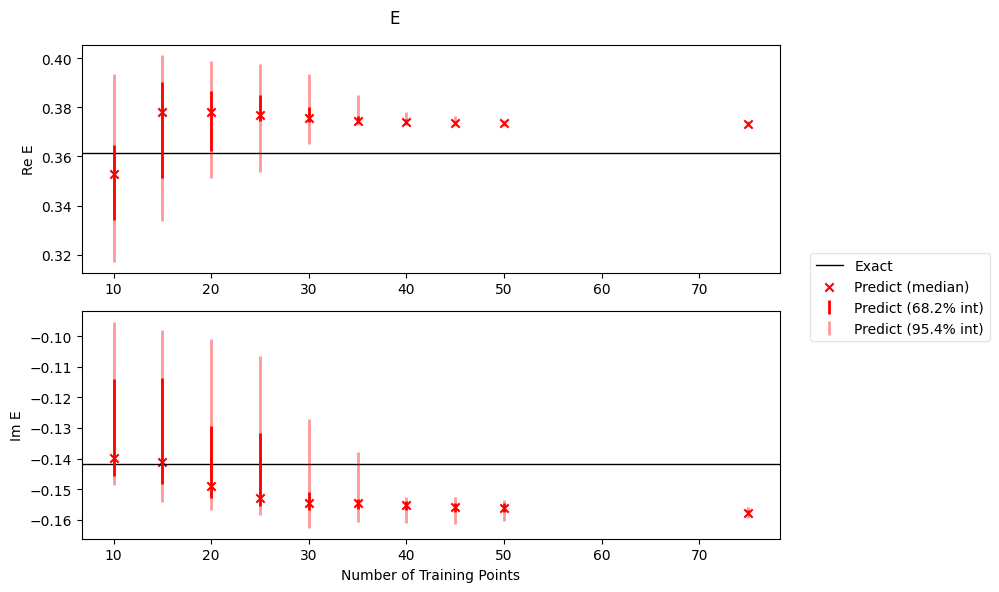

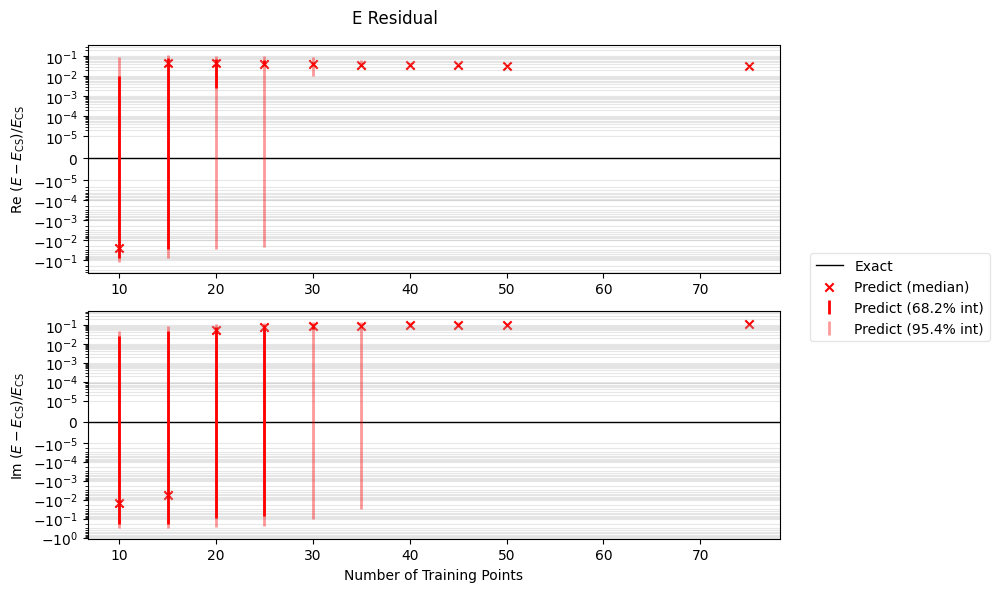

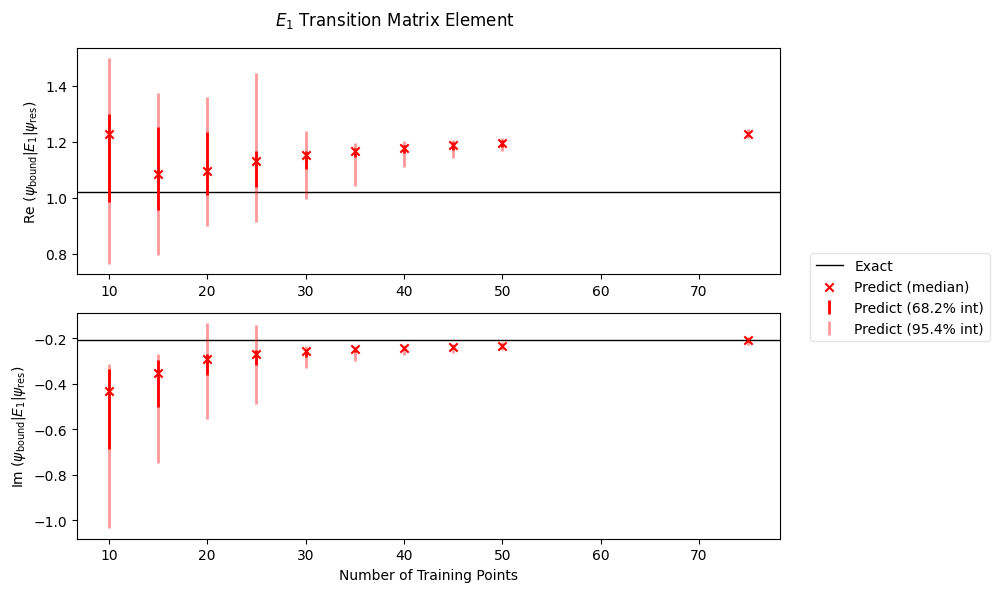

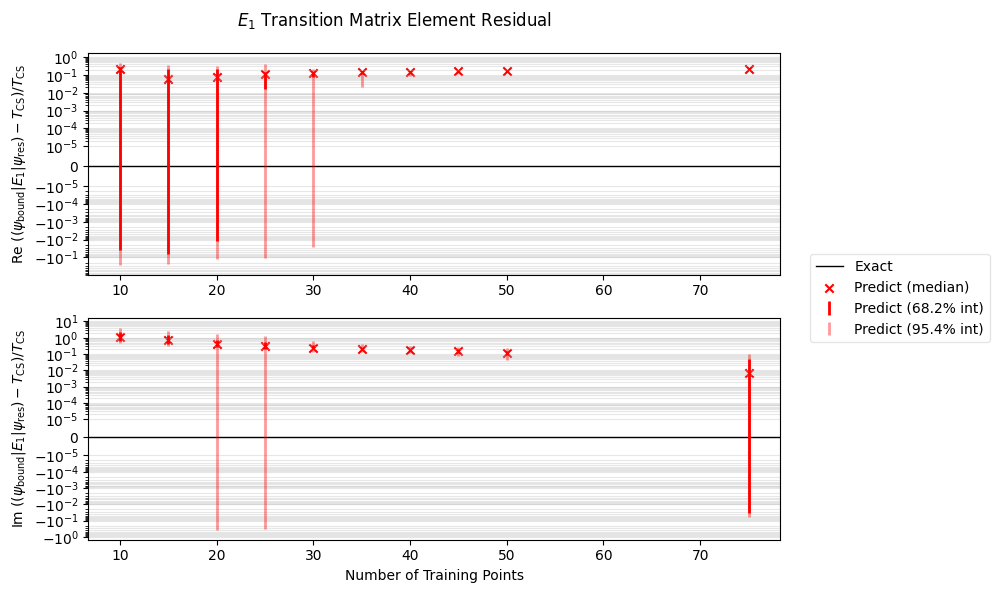

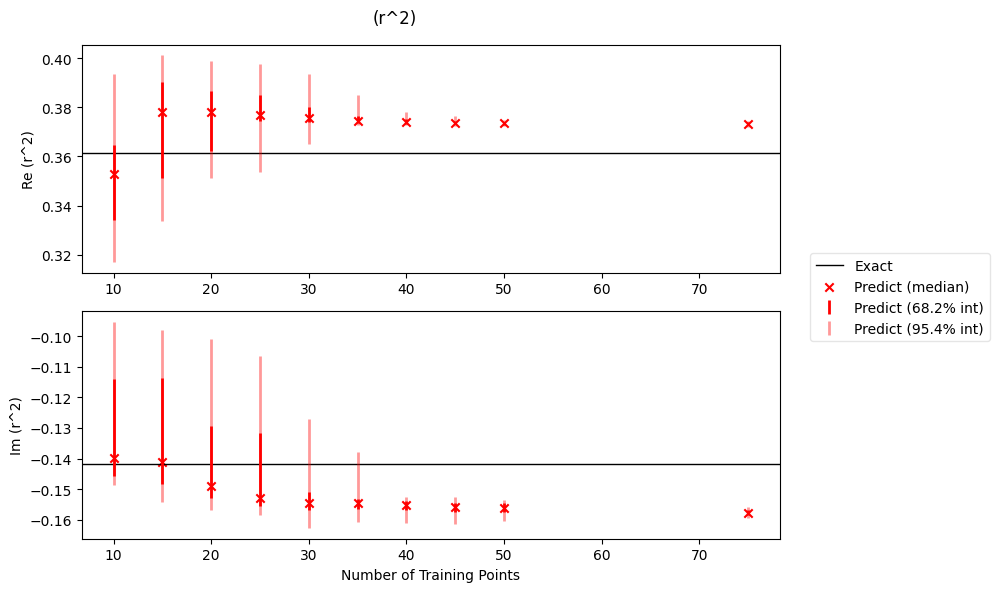

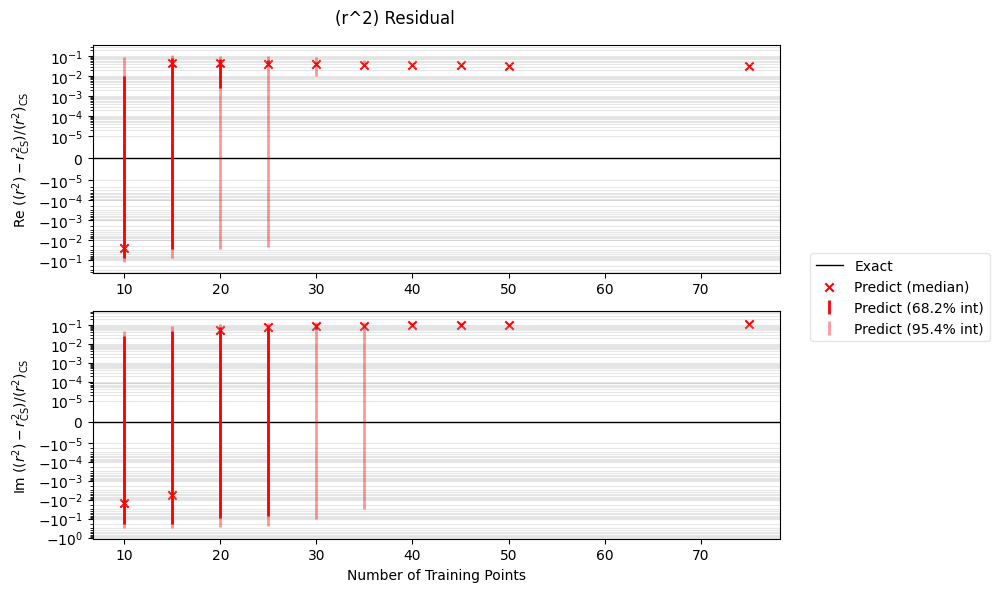

In [22]:
import matplotlib.ticker as mticker
def plot(fig, ax, exact, xs, data, **kwargs):
    axreal, aximag = ax
    # get stats from data
    med, err68, err95 = decompose_stats(data)

    # get plot kwargs
    title = kwargs.get("title", "")
    ylabel = kwargs.get("ylabel", "")
    xlabel = kwargs.get("xlabel", "")
    scale = kwargs.get("scale", "linear")
    cutoff = kwargs.get("cutoff", 0)
    color = kwargs.get("color", "red")

    # plot real and imaginary components
    axreal.axhline(y=np.real(exact), color='black', linewidth=1.0, linestyle='-', label='Exact')
    aximag.axhline(y=np.imag(exact), color='black', linewidth=1.0, linestyle='-', label='Exact')
    plot_stats(fig, (axreal, aximag), xs, med, err68, err95, cutoff=cutoff, color=color)

    # set labels, title, and legend
    axreal.set_ylabel(f"Re {ylabel}")
    aximag.set_ylabel(f"Im {ylabel}")
    aximag.set_xlabel(xlabel)
    #axreal.set_xlabel(xlabel)
    if scale=="symlog":
        axreal.set_yscale(scale, linthresh=1e-5)
        aximag.set_yscale(scale, linthresh=1e-5)
        for ax in (axreal, aximag):
            ax.yaxis.set_major_locator(mticker.SymmetricalLogLocator(base=10, linthresh=1e-5))
            ax.yaxis.set_minor_locator(mticker.SymmetricalLogLocator(base=10, linthresh=1e-5,
                                                                      subs=np.arange(2, 10)))
            ax.grid(True, which='both', axis='y', alpha=0.3)
    else:
        axreal.set_yscale(scale)
        aximag.set_yscale(scale)
    fig.suptitle(f"{title}")

    handles, labels = axreal.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), framealpha=0.5)
    axreal.legend().remove()
    aximag.legend().remove()
    return fig, (axreal, aximag)
    
# Plot energy and energy residuals
figsize=(8, 6)
cutoff=2
fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": "E", "xlabel": r"Number of Training Points", "title": "E", "cutoff": cutoff}
_ = plot(fig, (axreal, aximag), real_res, num_phi_points_list, all_energy_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system7_ec_backrotated_E_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$(E - E_\text{CS})/E_\text{CS}$", "cutoff": cutoff, "xlabel": r"Number of Training Points", "title": "E Residual", "scale": "symlog"}
_ = plot(fig, (axreal, aximag), 0.0+1j*0.0, num_phi_points_list, all_energy_resid_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system7_ec_backrotated_Eresid_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$(\psi_\text{bound}|E_1|\psi_\text{res})$", "xlabel": 
               r"Number of Training Points", "cutoff": cutoff, "title": r"$E_1$ Transition Matrix Element"}
_ = plot(fig, (axreal, aximag), real_telem, num_phi_points_list, all_telems_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system7_ec_backrotated_telem_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$((\psi_\text{bound}|E_1|\psi_\text{res})-T_\text{CS})/T_\text{CS}$", "cutoff": cutoff,
               "xlabel": r"Number of Training Points", "title": r"$E_1$ Transition Matrix Element Residual", "scale": "symlog"}
_ = plot(fig, (axreal, aximag), 0.0, num_phi_points_list, all_telems_resid_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system7_ec_backrotated_telem_resid_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"(r^2)", "xlabel": r"Number of Training Points", "title": "(r^2)", "cutoff": cutoff}
_ = plot(fig, (axreal, aximag), real_res, num_phi_points_list, all_energy_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system7_ec_backrotated_rr_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$((r^2) - r^2_\text{CS})/(r^2)_\text{CS}$", "cutoff": cutoff, "xlabel": r"Number of Training Points", "title": r"(r^2) Residual", "scale": "symlog"}
_ = plot(fig, (axreal, aximag), 0.0+1j*0.0, num_phi_points_list, all_energy_resid_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system7_ec_backrotated_rr_resid_wrt_trainingpoints.png")
plt.show()